# Classification — Category Recap

> **Goal:** predict a discrete label $y \in \{1, \dots, K\}$ from features $x$.

This notebook ties together the nine classification notebooks
([08](illustrated_08_classification_logistic_regression.ipynb)–[16](illustrated_16_classification_xgboost.ipynb))
into a single decision panel and head-to-head decision-boundary benchmark.

**Algorithms covered:**

| # | Algorithm | Notebook | Family |
|---|---|---|---|
| 08 | Logistic Regression | [logreg](illustrated_08_classification_logistic_regression.ipynb) | Linear, discriminative |
| 09 | Perceptron | [perceptron](illustrated_09_classification_perceptron.ipynb) | Linear, online |
| 10 | GDA / LDA / QDA | [gda](illustrated_10_classification_gda.ipynb) | Linear-Gaussian, generative |
| 11 | Naive Bayes | [nb](illustrated_11_classification_naive_bayes.ipynb) | Generative, conditional indep |
| 12 | KNN | [knn](illustrated_12_classification_knn.ipynb) | Non-parametric, lazy |
| 13 | SVM | [svm](illustrated_13_classification_svm.ipynb) | Margin-based, kernels |
| 14 | Decision Tree | [tree](illustrated_14_classification_decision_tree.ipynb) | Recursive partitioning |
| 15 | Random Forest | [rf](illustrated_15_classification_random_forest.ipynb) | Bagged trees |
| 16 | XGBoost | [xgb](illustrated_16_classification_xgboost.ipynb) | Boosted trees |


## Cheat-sheet — classification algorithm landscape

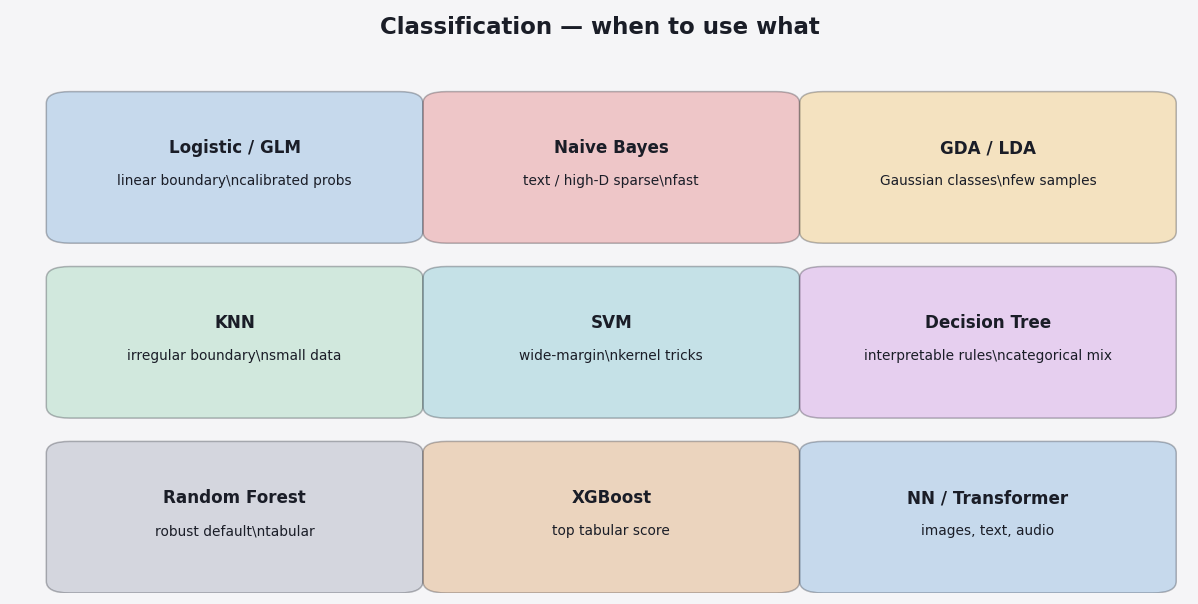

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 5.6)); ax.axis('off')
ax.text(0.5, 0.96, 'Classification — when to use what', ha='center', fontsize=15, weight='bold')
items = [('Logistic / GLM', 'linear boundary\\ncalibrated probs'), ('Naive Bayes', 'text / high-D sparse\\nfast'), ('GDA / LDA', 'Gaussian classes\\nfew samples'), ('KNN', 'irregular boundary\\nsmall data'), ('SVM', 'wide-margin\\nkernel tricks'), ('Decision Tree', 'interpretable rules\\ncategorical mix'), ('Random Forest', 'robust default\\ntabular'), ('XGBoost', 'top tabular score'), ('NN / Transformer', 'images, text, audio')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Property comparison

| Property | LogReg | Perceptron | GDA | NB | KNN | SVM-RBF | Tree | RF | XGB |
|---|---|---|---|---|---|---|---|---|---|
| Probabilistic output | ✅ | ❌ | ✅ | ✅ | partial | partial | partial | partial | partial |
| Linear boundary | ✅ | ✅ | ✅ | ✅ | ❌ | ❌ | ❌ | ❌ | ❌ |
| Handles non-linear | ❌ | ❌ | ❌ | ❌ | ✅ | ✅ | ✅ | ✅ | ✅ |
| Robust to feature scale | ❌ | ❌ | ❌ | ❌ | ❌ | ❌ | ✅ | ✅ | ✅ |
| Interpretable | ✅ coefs | partial | ✅ | ✅ | ❌ | ❌ | ✅ rule | partial | partial |
| Big data scaling | ✅ | ✅ | ✅ | ✅ | ❌ | ❌ | ✅ | ✅ | ✅ |
| Default first try | ✅ | ❌ | ✅ small | ✅ text | ❌ | ✅ | ❌ alone | ✅ | ✅ |

---
## Decision rule

```
Need probabilities + linear boundary OK?
├── Yes → Logistic Regression
└── No  →  features ≪ samples and Gaussian-ish?
            ├── Yes → LDA / QDA
            └── No  →  text or huge sparse?
                       ├── Yes → Multinomial Naive Bayes
                       └── No  → SVM (small/clean) or Random Forest (default tabular)
                                  ↓ if you need top accuracy → XGBoost / LightGBM
```


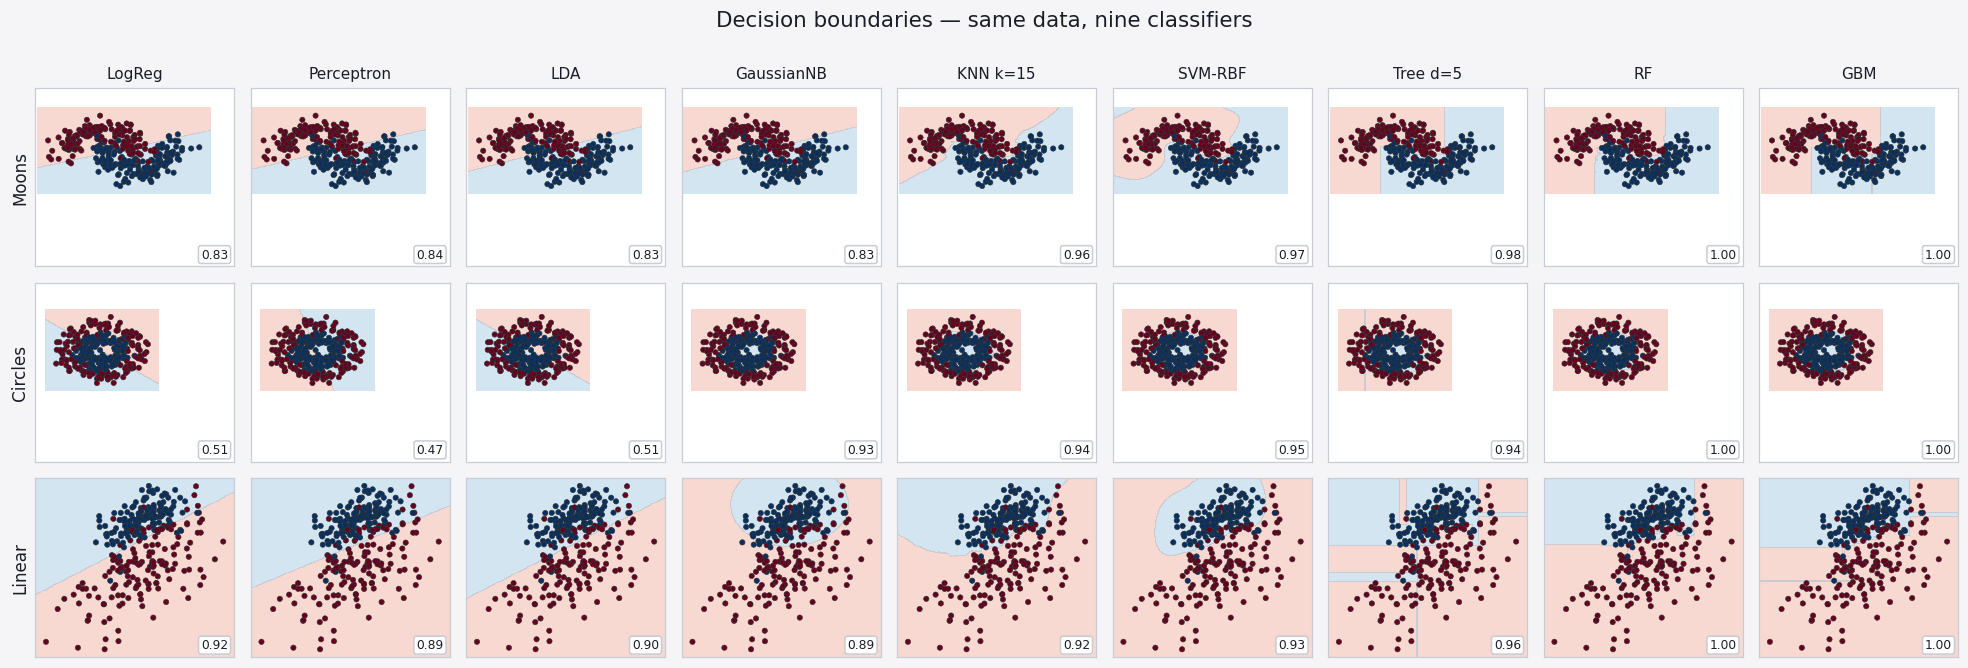

In [3]:
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

datasets = [
    ('Moons',  make_moons(n_samples=300, noise=0.25, random_state=0)),
    ('Circles', make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=0)),
    ('Linear', make_classification(n_samples=300, n_features=2, n_informative=2,
                                    n_redundant=0, n_clusters_per_class=1, random_state=0)),
]

clfs = {
    'LogReg'   : make_pipeline(StandardScaler(), LogisticRegression()),
    'Perceptron': make_pipeline(StandardScaler(), Perceptron(random_state=0)),
    'LDA'      : LinearDiscriminantAnalysis(),
    'GaussianNB': GaussianNB(),
    'KNN k=15' : make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    'SVM-RBF'  : make_pipeline(StandardScaler(), SVC(gamma=2, C=1)),
    'Tree d=5' : DecisionTreeClassifier(max_depth=5, random_state=0),
    'RF'       : RandomForestClassifier(n_estimators=100, random_state=0),
    'GBM'      : GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=0),
}

fig, axes = plt.subplots(len(datasets), len(clfs), figsize=(2.0*len(clfs), 2.0*len(datasets)),
                          sharex=True, sharey=True)

for r, (dname, (X, y)) in enumerate(datasets):
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.3, X[:,0].max()+0.3, 200),
                          np.linspace(X[:,1].min()-0.3, X[:,1].max()+0.3, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    for c, (name, clf) in enumerate(clfs.items()):
        ax = axes[r, c]
        clf.fit(X, y)
        Z = clf.predict(grid).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=[-0.1,0.5,1.1])
        ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', s=12, edgecolors='#333', linewidths=0.4)
        score = clf.score(X, y)
        if r == 0: ax.set_title(name, fontsize=10)
        if c == 0: ax.set_ylabel(dname, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.97, 0.03, f'{score:.2f}', transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.2', fc='#ffffff', ec='#c8ccd4'))

fig.suptitle('Decision boundaries — same data, nine classifiers', y=1.005, fontsize=14)
fig.tight_layout()
plt.show()


---
## Reading the grid

- **Row 1 (moons)** — only non-linear methods (KNN, SVM-RBF, trees, ensembles) work.
- **Row 2 (circles)** — same conclusion. Linear classifiers are stuck.
- **Row 3 (linear)** — every method works; **simpler models (LogReg, LDA) have the cleanest boundary** because they don't try to fit noise.

> Lesson: don't reach for a forest when a line will do.
> The simplest boundary that fits is also the one that **generalises best**.


---
## Summary

- Each algorithm in this category attacks a **different shape of problem**.
- The decision rule above is a heuristic, not a law — always benchmark.
- Read the linked deep-dive notebook for derivations, failure modes and exercises.

> Continue to the other recap notebooks: [Regression](illustrated_00_recap_regression.ipynb) ·
> [Classification](illustrated_00_recap_classification.ipynb) ·
> [Ensembles](illustrated_00_recap_ensembles.ipynb) ·
> [Clustering](illustrated_00_recap_clustering.ipynb) ·
> [Dim. Reduction](illustrated_00_recap_dim_reduction.ipynb) ·
> [Anomaly Detection](illustrated_00_recap_anomaly_detection.ipynb) ·
> [Time Series](illustrated_00_recap_time_series.ipynb) ·
> [RL](illustrated_00_recap_reinforcement_learning.ipynb).
